In [25]:
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import joblib

In [2]:
data= pd.read_csv("../data/Resultados_únicos_Saber_11_Santander.csv")

### Selecciono únicamente las columnas relacionadas con la pregunta que quiero responder

In [3]:
data_sample= data[
    ["FAMI_CUARTOSHOGAR", "FAMI_EDUCACIONMADRE", "FAMI_EDUCACIONPADRE", "FAMI_ESTRATOVIVIENDA", "FAMI_PERSONASHOGAR", "PUNT_GLOBAL"]
].dropna()

### Voy a reagrupar categorías para la columna "FAMI_CUARTOSHOGAR", partícularmente para las categorías con muy pocas observaciones

In [4]:
data_sample["FAMI_CUARTOSHOGAR"].unique()

<StringArray>
[      'Tres',     'Cuatro',        'Dos',       'Seis',      'Cinco',
        'Uno', 'Seis o mas',      'Nueve',      'Siete', 'Diez o más',
       'Ocho']
Length: 11, dtype: str

In [5]:
cuartos_count= data_sample.groupby(["FAMI_CUARTOSHOGAR"])["PUNT_GLOBAL"].count().reset_index()
cuartos_count["_Cuartos_Hogar"]= np.where(
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Seis") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Siete") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Ocho") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Nueve") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Diez o más") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Seis o mas") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Cinco") |
    (cuartos_count["FAMI_CUARTOSHOGAR"]== "Cuatro"),
    "Cuatro o más",
    cuartos_count["FAMI_CUARTOSHOGAR"]
)

In [6]:
cuart= cuartos_count[["FAMI_CUARTOSHOGAR", "_Cuartos_Hogar"]].drop_duplicates()
cuart

,FAMI_CUARTOSHOGAR,_Cuartos_Hogar
0,Cinco,Cuatro o más
1,Cuatro,Cuatro o más
2,Diez o más,Cuatro o más
3,Dos,Dos
4,Nueve,Cuatro o más
5,Ocho,Cuatro o más
6,Seis,Cuatro o más
7,Seis o mas,Cuatro o más
8,Siete,Cuatro o más
9,Tres,Tres


### Pinto el gráfico para visualizar si mejoró un poco la distribución por las categorías agrupadas

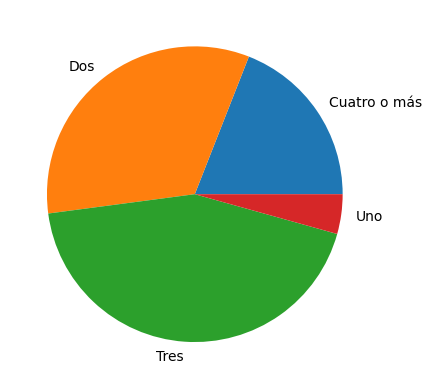

In [7]:
_cuartos_count= cuartos_count.groupby(["_Cuartos_Hogar"])["PUNT_GLOBAL"].sum().reset_index()
plt.pie(x= _cuartos_count["PUNT_GLOBAL"], labels= _cuartos_count["_Cuartos_Hogar"])
plt.show()

### Para las columnas "FAMI_EDUCACIONPADRE" y "FAMI_EDUCACIONMADRE", también agrupo algunas categorías para que la muestra esté mejor distribuida

In [8]:
education_parents= sorted(data_sample["FAMI_EDUCACIONPADRE"].unique().tolist())
education_parents

['Educación profesional completa',
 'Educación profesional incompleta',
 'Ninguno',
 'No Aplica',
 'No sabe',
 'Postgrado',
 'Primaria completa',
 'Primaria incompleta',
 'Secundaria (Bachillerato) completa',
 'Secundaria (Bachillerato) incompleta',
 'Técnica o tecnológica completa',
 'Técnica o tecnológica incompleta']

In [9]:
def unificar_categorias_educacion(df, columna):
    educacion_df= df.groupby(columna)["PUNT_GLOBAL"].count().reset_index()
    option= [
        educacion_df[columna]== "Educación profesional completa",
        educacion_df[columna]== "Técnica o tecnológica completa",
        (educacion_df[columna]== "Educación profesional incompleta") |
        (educacion_df[columna]== "Técnica o tecnológica incompleta") |
        (educacion_df[columna]== "Secundaria (Bachillerato) completa"),
        (educacion_df[columna]== "Secundaria (Bachillerato) incompleta") |
        (educacion_df[columna]== "Primaria completa"),
        (educacion_df[columna]== "Primaria incompleta") |
        (educacion_df[columna]== "Ninguno"),
        (educacion_df[columna]== "No sabe") |
        (educacion_df[columna]== "No Aplica")
    ]
    select= [
        "Profesional",
        "Técnico o Tecnológico",
        "Bachiller",
        "Primaria",
        "Ninguno",
        "No Sabe"
    ]
    educacion_df[f"_educacion_{columna[-5: ]}"]= np.select(option, select, educacion_df[columna])
    return educacion_df[[columna, f"_educacion_{columna[-5: ]}"]].drop_duplicates()

In [10]:
edu_madre= unificar_categorias_educacion(data_sample, "FAMI_EDUCACIONMADRE")
edu_padre= unificar_categorias_educacion(data_sample, "FAMI_EDUCACIONPADRE")

### Para la columna "FAMI_ESTRATOVIVIENDA" agrupo para los estratos iguales o mayores al 4 en una sola categoría

In [11]:
data_sample.groupby(["FAMI_ESTRATOVIVIENDA"])["PUNT_GLOBAL"].count().reset_index()

,FAMI_ESTRATOVIVIENDA,PUNT_GLOBAL
0,Estrato 1,69083
1,Estrato 2,67490
2,Estrato 3,40687
3,Estrato 4,15378
4,Estrato 5,3418
5,Estrato 6,2141
6,Sin Estrato,2126


In [12]:
def estrato_fam(df):
    est_df= df.copy()
    est_df["Fami_Estrato"]= np.where(
        est_df["FAMI_ESTRATOVIVIENDA"]== "Sin Estrato",
        "Estrato 1",
        np.where(
            (est_df["FAMI_ESTRATOVIVIENDA"]== "Estrato 4") | 
            (est_df["FAMI_ESTRATOVIVIENDA"]== "Estrato 5") |
            (est_df["FAMI_ESTRATOVIVIENDA"]== "Estrato 6"),
            "Estrato >= 4",
            est_df["FAMI_ESTRATOVIVIENDA"]
        )
    )
    return est_df[["FAMI_ESTRATOVIVIENDA", "Fami_Estrato"]].drop_duplicates()

In [13]:
est_v= estrato_fam(data_sample)
est_v

,FAMI_ESTRATOVIVIENDA,Fami_Estrato
0,Estrato 3,Estrato 3
2,Estrato 1,Estrato 1
5,Estrato 2,Estrato 2
9,Estrato 4,Estrato >= 4
70,Estrato 5,Estrato >= 4
109,Sin Estrato,Estrato 1
112,Estrato 6,Estrato >= 4


### Hago la misma tarea de agrupar categorías con poca representación en los datos, ahora para la columna "FAMI_PERSONASHOGAR"

In [14]:
data_sample["FAMI_PERSONASHOGAR"].unique()

<StringArray>
[     '3 a 4',      '5 a 6',      'Siete',      'Cinco',     'Cuatro',
        'Dos',       'Seis',      '7 a 8',       'Tres',    '9 o más',
        'Una',       'Once',       'Ocho', 'Doce o más',       'Diez',
      '1 a 2',      'Nueve']
Length: 17, dtype: str

In [15]:
data_sample.groupby(["FAMI_PERSONASHOGAR"])["PUNT_GLOBAL"].count().reset_index().sort_values(by= ["PUNT_GLOBAL"])

,FAMI_PERSONASHOGAR,PUNT_GLOBAL
12,Once,217
8,Doce o más,389
16,Una,440
7,Diez,577
10,Nueve,792
11,Ocho,1984
4,9 o más,2481
9,Dos,3649
14,Siete,3913
3,7 a 8,8171


In [16]:
def unificar_per_hogar(df):
    df_count= df.groupby(["FAMI_PERSONASHOGAR"])["PUNT_GLOBAL"].count().reset_index()
    select= [
        (df_count["FAMI_PERSONASHOGAR"]== "Una") | (df_count["FAMI_PERSONASHOGAR"]== "Dos") | (df_count["FAMI_PERSONASHOGAR"]== "1 a 2"),
        (df_count["FAMI_PERSONASHOGAR"]== "Tres") | (df_count["FAMI_PERSONASHOGAR"]== "Cuatro") | (df_count["FAMI_PERSONASHOGAR"]== "3 a 4"),
        (df_count["FAMI_PERSONASHOGAR"]== "Cinco") | (df_count["FAMI_PERSONASHOGAR"]== "Seis") | (df_count["FAMI_PERSONASHOGAR"]== "5 a 6"),
    ]
    option= [
        "1 a 2",
        "3 a 4",
        "5 a 6"
    ]
    df_count["_Num_Pers_Hogar"]= np.select(select, option, "> 6")
    return df_count[["FAMI_PERSONASHOGAR", "_Num_Pers_Hogar"]].drop_duplicates()

In [17]:
fam_hog= unificar_per_hogar(data_sample)
fam_hog

,FAMI_PERSONASHOGAR,_Num_Pers_Hogar
0,1 a 2,1 a 2
1,3 a 4,3 a 4
2,5 a 6,5 a 6
3,7 a 8,> 6
4,9 o más,> 6
5,Cinco,5 a 6
6,Cuatro,3 a 4
7,Diez,> 6
8,Doce o más,> 6
9,Dos,1 a 2


### Ahora reemplazo las nuevas categorías por columnas en la muestra de datos

In [18]:
data_samp_cuart= pd.merge(data_sample, cuart, how= "left", on= ["FAMI_CUARTOSHOGAR"])
data_samp_fmmadre= pd.merge(data_samp_cuart, edu_madre, how= "left", on= ["FAMI_EDUCACIONMADRE"])
data_samp_fmpadre= pd.merge(data_samp_fmmadre, edu_padre, how= "left", on= ["FAMI_EDUCACIONPADRE"])
data_samp_est= pd.merge(data_samp_fmpadre, est_v, how= "left", on= ["FAMI_ESTRATOVIVIENDA"])
clean_data_samp= pd.merge(data_samp_est, fam_hog, how= "left", on= ["FAMI_PERSONASHOGAR"])
clean_data_samp.drop(columns= ["FAMI_CUARTOSHOGAR", "FAMI_EDUCACIONMADRE", "FAMI_EDUCACIONPADRE", "FAMI_ESTRATOVIVIENDA", "FAMI_PERSONASHOGAR"], inplace= True)

In [ ]:
clean_data_samp

### Calcular las estadísticas descriptivas generales del puntaje global 

In [44]:
mean_gp= clean_data_samp["PUNT_GLOBAL"].mean()
std_gp= clean_data_samp["PUNT_GLOBAL"].std()
cv_gp= std_gp/ mean_gp
print(f"Promedio general del puntaje global: {mean_gp: .2f}")
print(f"Desviación estándar general del puntaje global: {std_gp: .2f}")
print(f"Coeficiente de variación general del puntaje global: {cv_gp: .2f}")

Promedio general del puntaje global:  265.69
Desviación estándar general del puntaje global:  51.46
Coeficiente de variación general del puntaje global:  0.19


In [45]:
clean_data_samp.to_csv("data_samp.csv", index= False)

In [20]:
X = clean_data_samp[['_Cuartos_Hogar', '_educacion_MADRE', '_educacion_PADRE', 'Fami_Estrato', "_Num_Pers_Hogar"]]
y = clean_data_samp['PUNT_GLOBAL']
cat_cols = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(160258, 5) (40065, 5) (160258,) (40065,)


In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [22]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [29]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_transformed.shape[1],)),
    Dropout(0.2),
    
    Dense(32, activation="relu"),
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    
    Dense(1)  # salida continua para regresión
])

c:\Users\ching\OneDrive\Documentos\Maestría\Analítica computacional para la toma de decisiones\Proyecto_2-1\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
history = model.fit(
    X_train_transformed,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - loss: 4754.2090 - mae: 49.9964 - val_loss: 2156.5618 - val_mae: 37.3731
Epoch 2/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 2786.1294 - mae: 42.2564 - val_loss: 3012.9653 - val_mae: 44.0965
Epoch 3/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 2494.7920 - mae: 40.0493 - val_loss: 3901.0630 - val_mae: 50.8083
Epoch 4/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - loss: 2411.5620 - mae: 39.3890 - val_loss: 4248.4844 - val_mae: 53.3507
Epoch 5/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 2372.2834 - mae: 39.1393 - val_loss: 3819.6355 - val_mae: 50.0098
Epoch 6/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 2330.9897 - mae: 38.8137 - val_loss: 3086.4736 - val_mae: 44.6311
Epoch 7/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 2295.2671 - mae: 38.5145 - val_loss: 4304.6890 - val_mae: 53.6529
Epoch 8/50
4007/4007 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 2255.8906 - mae: 38.1912 - val_los

In [ ]:
def plotting_history(history: Sequential.fit)-> None:
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(8,5))
    plt.plot(hist['epoch'], hist['loss'], label='Pérdida entrenamiento')
    plt.plot(hist['epoch'], hist['val_loss'], label='Pérdida validación')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio (MSE)')
    plt.title('Historial de pérdida del modelo base')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def model_performance(data: dict)-> tuple[float, float, float]:
    model= data["Model"]
    to_predict= data["X_test_transformed"]
    y_test= data["Y_test"]
    y_pred = model.predict(to_predict).ravel()
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2

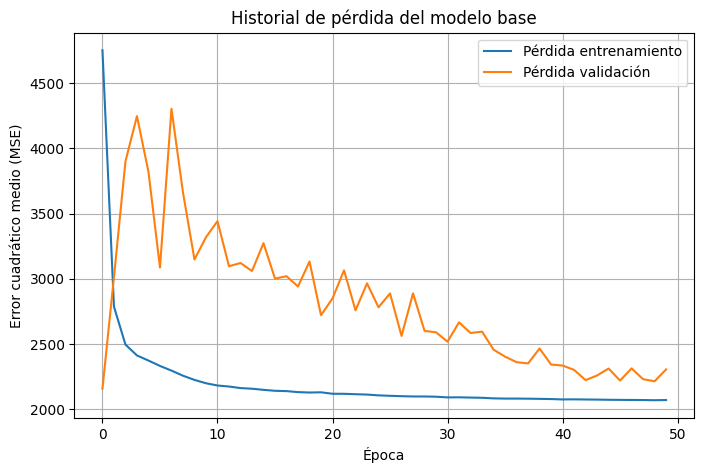

1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
MAE Model 1: 38.319283822251364
RMSE Model 1: 2274.241086897348
R2 Model 1: 0.1384282569084967


In [ ]:
plotting_history(history)
m1_mae, m1_rmse, m1_r2= model_performance(
    {
        "Model": model,
        "X_test_transformed": X_test_transformed,
        "Y_test": y_test
    }
)
print(f"MAE Model 1: {m1_mae}")
print(f"RMSE Model 1: {m1_rmse}")
print(f"R2 Model 1: {m1_r2}")

In [ ]:
model_2 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_transformed.shape[1],)),
    Dropout(0.2),    
    Dense(32, activation="relu"),
    Dropout(0.2),    
    Dense(16, activation="relu"),    
    Dense(1)  # salida continua para regresión
])
model_2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
history_2 = model_2.fit(
    X_train_transformed,
    y_train,
    validation_split=0.2,
    epochs= 35,
    batch_size= 100,
    verbose= 1
)

c:\Users\ching\OneDrive\Documentos\Maestría\Analítica computacional para la toma de decisiones\Proyecto_2-1\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 8236.5771 - mae: 62.3169 - val_loss: 2098.5352 - val_mae: 36.9160
Epoch 2/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 3003.0342 - mae: 43.8451 - val_loss: 2137.3325 - val_mae: 37.2021
Epoch 3/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2954.6736 - mae: 43.5076 - val_loss: 2182.1482 - val_mae: 37.5774
Epoch 4/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 2800.5242 - mae: 42.3909 - val_loss: 2614.3525 - val_mae: 41.0268
Epoch 5/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2636.5898 - mae: 41.1658 - val_loss: 3327.2720 - val_mae: 46.5560
Epoch 6/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2516.7073 - mae: 40.2396 - val_loss: 3715.5964 - val_mae: 49.4303
Epoch 7/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2476.3335 - mae: 39.9476 - val_loss: 3595.5781 - val_mae: 48.5358
Epoch 8/35
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 2442.6887 - mae: 39.6967 - val_loss: 4116

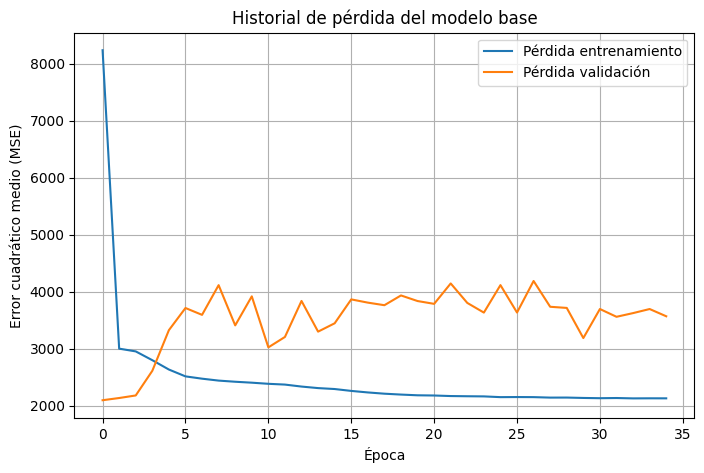

1253/1253 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
MAE Model 2: 47.74796812075824
RMSE Model 2: 3498.532480787353
R2 Model 2: -0.32538135253127387


In [ ]:
plotting_history(history_2)
m2_mae, m2_rmse, m2_r2= model_performance(
    {
        "Model": model_2,
        "X_test_transformed": X_test_transformed,
        "Y_test": y_test
    }
)
print(f"MAE Model 2: {m2_mae}")
print(f"RMSE Model 2: {m2_rmse}")
print(f"R2 Model 2: {m2_r2}")

In [ ]:
model_3 = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_transformed.shape[1],)),
    Dropout(0.2),    
    Dense(32, activation="relu"),
    Dropout(0.2),    
    Dense(16, activation="relu"),    
    Dropout(0.2),
    Dense(8, activation="relu"),    
    Dense(1)  # salida continua para regresión
])
model_3.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
history_3 = model_3.fit(
    X_train_transformed,
    y_train,
    validation_split=0.2,
    epochs= 50,
    batch_size= 50,
    verbose= 1
)

c:\Users\ching\OneDrive\Documentos\Maestría\Analítica computacional para la toma de decisiones\Proyecto_2-1\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 6307.4272 - mae: 57.5683 - val_loss: 5339.5405 - val_mae: 61.0655
Epoch 2/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 3310.6353 - mae: 45.8256 - val_loss: 4779.0669 - val_mae: 57.0917
Epoch 3/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 3187.1711 - mae: 44.9415 - val_loss: 4592.8062 - val_mae: 55.8426
Epoch 4/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 3088.3816 - mae: 44.3050 - val_loss: 5711.9727 - val_mae: 63.5125
Epoch 5/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 2963.3411 - mae: 43.4204 - val_loss: 4465.7051 - val_mae: 54.7818
Epoch 6/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 2821.6011 - mae: 42.4166 - val_loss: 3921.7078 - val_mae: 50.8196
Epoch 7/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 2639.1392 - mae: 41.0757 - val_loss: 3858.3738 - val_mae: 50.3425
Epoch 8/50
2565/2565 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 2495.1118 - mae: 40.0320 - val_los

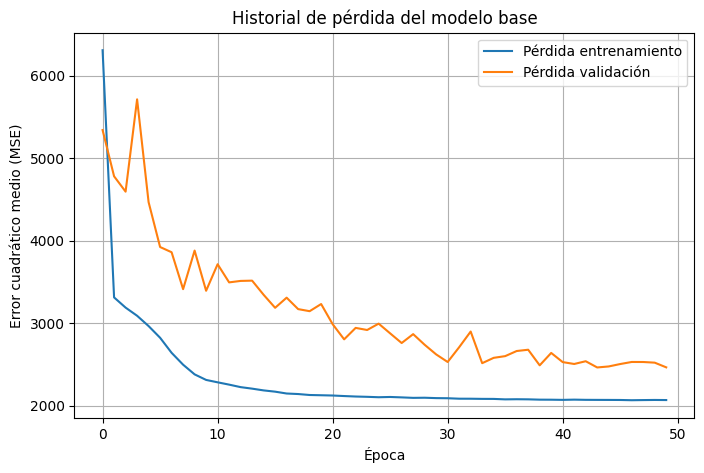

1253/1253 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
MAE Model 3: 39.476877814030715
RMSE Model 3: 2423.9050108478964
R2 Model 3: 0.0817296911412656


In [ ]:
plotting_history(history_3)
m3_mae, m3_rmse, m3_r2= model_performance(
    {
        "Model": model_3,
        "X_test_transformed": X_test_transformed,
        "Y_test": y_test
    }
)
print(f"MAE Model 3: {m3_mae}")
print(f"RMSE Model 3: {m3_rmse}")
print(f"R2 Model 3: {m3_r2}")

In [ ]:
model.save("modelo_punt_global.keras")

In [ ]:
joblib.dump(preprocessor, "preprocessor.joblib")

['preprocessor.joblib']

In [ ]:
from sklearn.cluster import KMeans

In [26]:
X_ = clean_data_samp[['_Cuartos_Hogar', '_educacion_MADRE', '_educacion_PADRE', 'Fami_Estrato', "_Num_Pers_Hogar"]]
X_transformed_ = preprocessor.transform(X)


N_PROFILES = 6
RANDOM_STATE = 42
N_BOOTSTRAPS = 300


kmeans = KMeans(
    n_clusters=N_PROFILES,
    random_state=RANDOM_STATE,
    n_init="auto"
)

profiles = kmeans.fit_predict(X_transformed_)

df_profiles = clean_data_samp.copy()
df_profiles["PROFILE_ID"] = profiles

In [27]:
profiles_mapping= {
    2: 0,
    5: 1,
    1: 2,
    0: 3,
    3: 4,
    4: 5

}
df_profiles["PROFILE_ID"]= df_profiles["PROFILE_ID"].map(profiles_mapping)

In [28]:
df_profiles.to_csv("data_samp.csv", index= False)